# Part2 Sample the rays

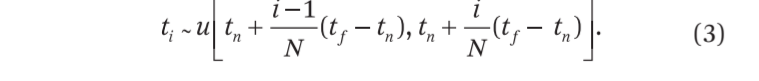

## import libraries

In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
from nerflab import (
    Intrinsics, Camera, CFG
)
from nerflab.camera.presets import pose_H, make_pose_cases
from nerflab.camera.sampling import stratified_samples_batch, cartesian_to_spherical


In [2]:
# build preset dictionary
cases = make_pose_cases(axis_dist=10)

# pick a view (e.g., diagonal)
H_wc = pose_H(cases["+Z"])  
print(H_wc)

tensor([[ 1.,  0., -0.,  0.],
        [-0.,  1., -0.,  0.],
        [ 0.,  0.,  1., 10.],
        [ 0.,  0.,  0.,  1.]])


In [3]:
# --- camera ------------------------------------------------------------------
intr  = Intrinsics(**CFG.intrinsics.__dict__)
cam   = Camera(H_wc, intr,
               t_bounds=(CFG.rays.t_near, CFG.rays.t_far))

# --- sample rays -------------------------------------------------------------
O_w, D_w = cam.get_rays(frame="world")
print(O_w.shape)
print(D_w.shape)
t, delta, pts = stratified_samples_batch(
    O_w, D_w, t_near = CFG.rays.t_near, t_far=CFG.rays.t_far,
    N=CFG.rays.N, deterministic=CFG.rays.deterministic
)
print("points shape:", pts.shape)

# Angles
_, theta, phi = cartesian_to_spherical(pts)
# --- visualise ---------------------------------------------------------------


# cam.plot_rays()

torch.Size([307200, 3])
torch.Size([307200, 3])
points shape: torch.Size([307200, 40, 3])


In [4]:
a = D_w[int(640*(480/2)+640/2)]
print(a)

tensor([ 0.,  0., -1.])


In [5]:
b = D_w[0]
print(b)

tensor([-0.2506,  0.2506, -0.9351])


In [6]:
print(a.dot(b))

tensor(0.9351)


In [7]:
640 * 480

307200

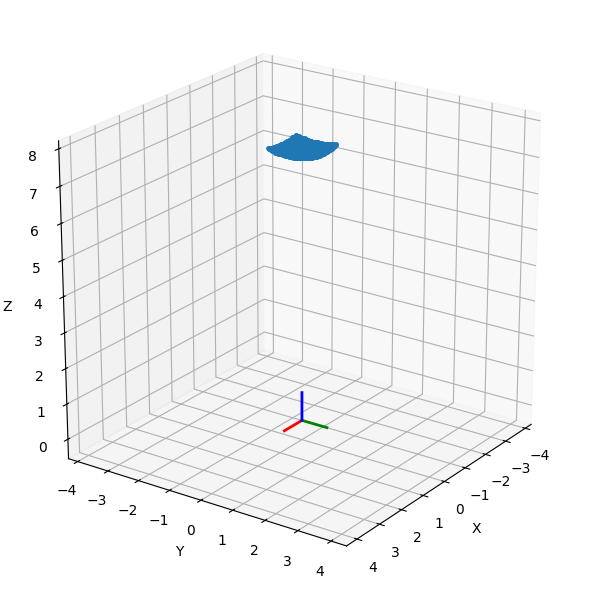

In [8]:
cam.plot_rays(mode='points', points=pts, step=5000)


In [9]:
pts.shape[-1]

3

In [10]:
pts[::5000].shape

torch.Size([62, 40, 3])

In [11]:
pts.shape

torch.Size([307200, 40, 3])

In [12]:
pts.reshape(-1,3).shape

torch.Size([12288000, 3])

In [13]:
pts.reshape(-1,3)[::100].shape

torch.Size([122880, 3])